In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

In [2]:
# For Data Processing
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image, ImageEnhance

# For ML Models
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.preprocessing.image import load_img

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
from tqdm import tqdm
import os
import random

In [3]:
train_dir = r'breastcancerdata/train'
test_dir = r'breastcancerdata/val'

train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(train_dir+"//" +label):
        train_paths.append(train_dir + '//'+label+ '//'+image)
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

In [4]:
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(test_dir+ '//' + label):
        test_paths.append(test_dir +'//'+label + '//'+image)
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

In [5]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

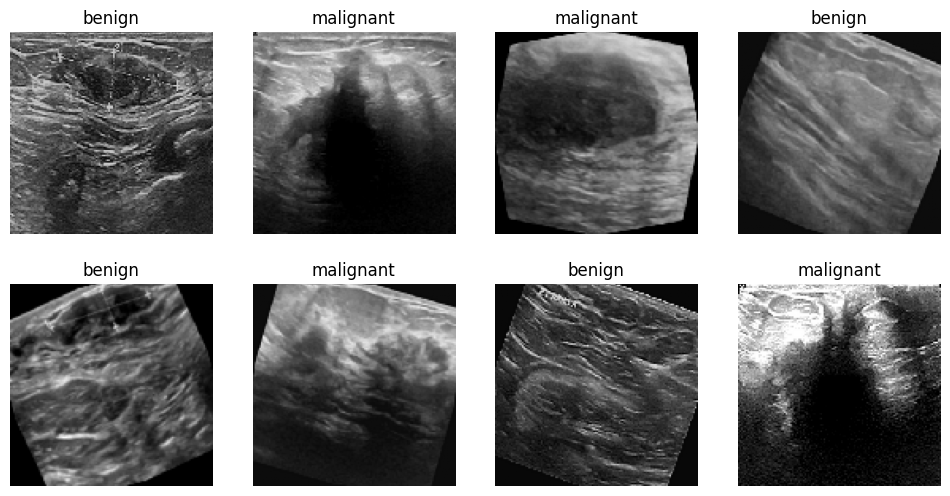

In [6]:
IMAGE_SIZE = 128


def open_images(paths):

    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)


images = open_images(train_paths[50:59])
labels = train_labels[50:59]
fig = plt.figure(figsize=(12, 6))
for x in range(1, 9):
    fig.add_subplot(2, 4, x)
    plt.axis('off')
    plt.title(labels[x])
    plt.imshow(images[x])
plt.rcParams.update({'font.size': 12})
plt.show()

In [7]:
unique_labels = os.listdir(train_dir)

def encode_label(labels):
    encoded = []
    for x in labels:
        encoded.append(unique_labels.index(x))
    return np.array(encoded)

def decode_label(labels):
    decoded = []
    for x in labels:
        decoded.append(unique_labels[x])
    return np.array(decoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for x in range(0, len(paths), batch_size):
            batch_paths = paths[x:x+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[x:x+batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [8]:

# Define Dense Block
def dense_block(input_tensor, filters, blocks):
    x = input_tensor
    for i in range(blocks):
        x = dense_unit(x, filters)
    return x

# Define Dense Unit
def dense_unit(input_tensor, filters):
    x = layers.BatchNormalization()(input_tensor)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.Concatenate()([input_tensor, x])
    return x

# Define Transition Block
def transition_block(input_tensor, reduction):
    filters = int(input_tensor.shape[-1] * reduction)
    x = layers.BatchNormalization()(input_tensor)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 1, padding='same')(x)
    x = layers.AveragePooling2D(2)(x)
    return x

# Define DenseNet model
def DenseNet(input_shape, num_classes, blocks_per_group, growth_rate, reduction):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    for i, blocks in enumerate(blocks_per_group):
        x = dense_block(x, growth_rate, blocks)
        if i != len(blocks_per_group) - 1:
            x = transition_block(x, reduction)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

In [9]:
# Create DenseNet model
DenseModel = DenseNet(input_shape=(128, 128, 3), num_classes=3, blocks_per_group=[6, 12, 24, 16], growth_rate=32, reduction=0.5)

print(DenseModel.summary())

# Compile the model
DenseModel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 64, 64, 64)           9472      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 64, 64, 64)           256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 64, 64, 64)           0         ['batch_normalization[0][0

                                                                                                  
 re_lu_7 (ReLU)              (None, 32, 32, 256)          0         ['batch_normalization_7[0][0]'
                                                                    ]                             
                                                                                                  
 conv2d_7 (Conv2D)           (None, 32, 32, 128)          32896     ['re_lu_7[0][0]']             
                                                                                                  
 average_pooling2d (Average  (None, 16, 16, 128)          0         ['conv2d_7[0][0]']            
 Pooling2D)                                                                                       
                                                                                                  
 batch_normalization_8 (Bat  (None, 16, 16, 128)          512       ['average_pooling2d[0][0]']   
 chNormali

 concatenate_12 (Concatenat  (None, 16, 16, 352)          0         ['concatenate_11[0][0]',      
 e)                                                                  'conv2d_14[0][0]']           
                                                                                                  
 batch_normalization_15 (Ba  (None, 16, 16, 352)          1408      ['concatenate_12[0][0]']      
 tchNormalization)                                                                                
                                                                                                  
 re_lu_15 (ReLU)             (None, 16, 16, 352)          0         ['batch_normalization_15[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_15 (Conv2D)          (None, 16, 16, 32)           101408    ['re_lu_15[0][0]']            
          

 re_lu_22 (ReLU)             (None, 8, 8, 288)            0         ['batch_normalization_22[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_22 (Conv2D)          (None, 8, 8, 32)             82976     ['re_lu_22[0][0]']            
                                                                                                  
 concatenate_19 (Concatenat  (None, 8, 8, 320)            0         ['concatenate_18[0][0]',      
 e)                                                                  'conv2d_22[0][0]']           
                                                                                                  
 batch_normalization_23 (Ba  (None, 8, 8, 320)            1280      ['concatenate_19[0][0]']      
 tchNormalization)                                                                                
          

 e)                                                                  'conv2d_29[0][0]']           
                                                                                                  
 batch_normalization_30 (Ba  (None, 8, 8, 544)            2176      ['concatenate_26[0][0]']      
 tchNormalization)                                                                                
                                                                                                  
 re_lu_30 (ReLU)             (None, 8, 8, 544)            0         ['batch_normalization_30[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_30 (Conv2D)          (None, 8, 8, 32)             156704    ['re_lu_30[0][0]']            
                                                                                                  
 concatena

                                                                    ']                            
                                                                                                  
 conv2d_37 (Conv2D)          (None, 8, 8, 32)             221216    ['re_lu_37[0][0]']            
                                                                                                  
 concatenate_34 (Concatenat  (None, 8, 8, 800)            0         ['concatenate_33[0][0]',      
 e)                                                                  'conv2d_37[0][0]']           
                                                                                                  
 batch_normalization_38 (Ba  (None, 8, 8, 800)            3200      ['concatenate_34[0][0]']      
 tchNormalization)                                                                                
                                                                                                  
 re_lu_38 

                                                                                                  
 batch_normalization_45 (Ba  (None, 8, 8, 1024)           4096      ['concatenate_41[0][0]']      
 tchNormalization)                                                                                
                                                                                                  
 re_lu_45 (ReLU)             (None, 8, 8, 1024)           0         ['batch_normalization_45[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_45 (Conv2D)          (None, 8, 8, 512)            524800    ['re_lu_45[0][0]']            
                                                                                                  
 average_pooling2d_2 (Avera  (None, 4, 4, 512)            0         ['conv2d_45[0][0]']           
 gePooling

                                                                                                  
 conv2d_52 (Conv2D)          (None, 4, 4, 32)             202784    ['re_lu_52[0][0]']            
                                                                                                  
 concatenate_48 (Concatenat  (None, 4, 4, 736)            0         ['concatenate_47[0][0]',      
 e)                                                                  'conv2d_52[0][0]']           
                                                                                                  
 batch_normalization_53 (Ba  (None, 4, 4, 736)            2944      ['concatenate_48[0][0]']      
 tchNormalization)                                                                                
                                                                                                  
 re_lu_53 (ReLU)             (None, 4, 4, 736)            0         ['batch_normalization_53[0][0]
          

 batch_normalization_60 (Ba  (None, 4, 4, 960)            3840      ['concatenate_55[0][0]']      
 tchNormalization)                                                                                
                                                                                                  
 re_lu_60 (ReLU)             (None, 4, 4, 960)            0         ['batch_normalization_60[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_60 (Conv2D)          (None, 4, 4, 32)             276512    ['re_lu_60[0][0]']            
                                                                                                  
 concatenate_56 (Concatenat  (None, 4, 4, 992)            0         ['concatenate_55[0][0]',      
 e)                                                                  'conv2d_60[0][0]']           
          

In [10]:
dense_net_history=DenseModel.fit(datagen(train_paths, train_labels, batch_size=32, epochs=10), steps_per_epoch=len(train_paths)//32, epochs=10)

Epoch 1/10
257/257 [==============================] - 675s 3s/step - loss: 1.3186 - accuracy: 0.6210
Epoch 2/10
257/257 [==============================] - 656s 3s/step - loss: 0.6444 - accuracy: 0.7282
Epoch 3/10
257/257 [==============================] - 636s 2s/step - loss: 0.4982 - accuracy: 0.7916
Epoch 4/10
257/257 [==============================] - 648s 3s/step - loss: 0.3883 - accuracy: 0.8439
Epoch 5/10
257/257 [==============================] - 639s 2s/step - loss: 0.3057 - accuracy: 0.8773
Epoch 6/10
257/257 [==============================] - 618s 2s/step - loss: 0.2361 - accuracy: 0.9091
Epoch 7/10
257/257 [==============================] - 617s 2s/step - loss: 0.1654 - accuracy: 0.9354
Epoch 8/10
257/257 [==============================] - 619s 2s/step - loss: 0.1427 - accuracy: 0.9495
Epoch 9/10
257/257 [==============================] - 614s 2s/step - loss: 0.1119 - accuracy: 0.9598
Epoch 10/10
257/257 [==============================] - 617s 2s/step - loss: 0.0949 - accura

In [11]:
# Define Residual Unit block
def residual_unit(input_tensor, filters, strides=(1, 1), activation='relu'):
    shortcut = input_tensor

    x = layers.Conv2D(filters, (3, 3), strides=strides, padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)

    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    if strides != (1, 1) or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=strides)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation(activation)(x)

    return x

# Define ResNet model
def ResNet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = residual_unit(x, 64)
    x = residual_unit(x, 64)
    x = residual_unit(x, 64)

    x = residual_unit(x, 128, strides=(2, 2))
    x = residual_unit(x, 128)
    x = residual_unit(x, 128)

    x = residual_unit(x, 256, strides=(2, 2))
    x = residual_unit(x, 256)
    x = residual_unit(x, 256)

    x = residual_unit(x, 512, strides=(2, 2))
    x = residual_unit(x, 512)
    x = residual_unit(x, 512)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


In [12]:
# Create ResNet model
ResModel = ResNet(input_shape=(128, 128, 3), num_classes=3)

print(ResModel.summary())

ResModel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

res_net_history=ResModel.fit(datagen(train_paths, train_labels, batch_size=32, epochs=10), steps_per_epoch=len(train_paths)//32, epochs=10)

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_62 (Conv2D)          (None, 64, 64, 64)           9472      ['input_2[0][0]']             
                                                                                                  
 batch_normalization_62 (Ba  (None, 64, 64, 64)           256       ['conv2d_62[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation (Activation)     (None, 64, 64, 64)           0         ['batch_normalization_62

 conv2d_71 (Conv2D)          (None, 16, 16, 128)          8320      ['activation_6[0][0]']        
                                                                                                  
 batch_normalization_70 (Ba  (None, 16, 16, 128)          512       ['conv2d_70[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 batch_normalization_71 (Ba  (None, 16, 16, 128)          512       ['conv2d_71[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 add_3 (Add)                 (None, 16, 16, 128)          0         ['batch_normalization_70[0][0]
                                                                    ',                            
          

 activation_15 (Activation)  (None, 8, 8, 256)            0         ['batch_normalization_79[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_80 (Conv2D)          (None, 8, 8, 256)            590080    ['activation_15[0][0]']       
                                                                                                  
 batch_normalization_80 (Ba  (None, 8, 8, 256)            1024      ['conv2d_80[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 add_7 (Add)                 (None, 8, 8, 256)            0         ['batch_normalization_80[0][0]
                                                                    ',                            
          

                                                                    ']                            
                                                                                                  
 conv2d_89 (Conv2D)          (None, 4, 4, 512)            2359808   ['activation_23[0][0]']       
                                                                                                  
 batch_normalization_89 (Ba  (None, 4, 4, 512)            2048      ['conv2d_89[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 add_11 (Add)                (None, 4, 4, 512)            0         ['batch_normalization_89[0][0]
                                                                    ',                            
                                                                     'activation_22[0][0]']       
          

In [13]:
def build_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(Flatten())
    model.add(Dense(16, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

CNN_model = build_model()
CNN_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_90 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 63, 63, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_91 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_92 (Conv2D)          (None, 28, 28, 32)        18464     
                                                                 
 flatten (Flatten)           (None, 25088)             0

In [14]:
CNN_model=CNN_model.fit(datagen(train_paths, train_labels, batch_size=32, epochs=10), steps_per_epoch=len(train_paths)//32, epochs=10)

Epoch 1/10
257/257 [==============================] - 65s 251ms/step - loss: 0.5444 - accuracy: 0.7552
Epoch 2/10
257/257 [==============================] - 68s 266ms/step - loss: 0.3107 - accuracy: 0.8809
Epoch 3/10
257/257 [==============================] - 67s 260ms/step - loss: 0.2028 - accuracy: 0.9256
Epoch 4/10
257/257 [==============================] - 68s 264ms/step - loss: 0.1265 - accuracy: 0.9523
Epoch 5/10
257/257 [==============================] - 67s 261ms/step - loss: 0.0853 - accuracy: 0.9688
Epoch 6/10
257/257 [==============================] - 68s 266ms/step - loss: 0.0528 - accuracy: 0.9810
Epoch 7/10
257/257 [==============================] - 68s 264ms/step - loss: 0.0405 - accuracy: 0.9874
Epoch 8/10
257/257 [==============================] - 69s 270ms/step - loss: 0.0334 - accuracy: 0.9891
Epoch 9/10
257/257 [==============================] - 68s 265ms/step - loss: 0.0202 - accuracy: 0.9935
Epoch 10/10
257/257 [==============================] - 68s 264ms/step - l

In [23]:
from tensorflow.keras.models import Model

# Ensemble model
def ensemble_model(models, input_shape):
    inputs = layers.Input(shape=input_shape)
    outputs = [model(inputs) for model in models]
    avg = layers.average(outputs)
    ensemble = Model(inputs, avg)
    return ensemble

ensemble_model = ensemble_model([DenseModel, ResModel, CNN_model], input_shape=(128, 128, 3))



TypeError: 'History' object is not callable

In [19]:
print(type(DenseModel))
print(type(ResModel))
print(type(CNN_model))


<class 'keras.src.engine.functional.Functional'>
<class 'keras.src.engine.functional.Functional'>
<class 'keras.src.callbacks.History'>


In [ ]:
# Save ensemble model
ensemble_model.save('ensemble_model.h5')


In [ ]:
# Training graphs
def plot_training(history, title):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.suptitle(title)
    plt.show()



In [ ]:
plot_training(dense_net_history, 'DenseNet Training')
plot_training(res_net_history, 'ResNet Training')
plot_training(CNN_model, 'CNN Training')

In [ ]:
batch_size = 32
steps = int(len(test_paths)/batch_size)
y_pred = []
y_true = []
for x,y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
    pred = ensemble_model.predict(x)
    pred = np.argmax(pred, axis=-1)
    for i in decode_label(pred):
        y_pred.append(i)
    for i in decode_label(y):
        y_true.append(i)

In [ ]:
print(classification_report(y_true, y_pred))

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):  # Assuming num_classes is the number of classes
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_pred.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Plot ROC curve for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve (class {i}), AUC = {roc_auc[i]:.2f}')

# Plot micro-average ROC curve
plt.plot(fpr_micro, tpr_micro, label=f'Micro-average ROC curve, AUC = {roc_auc_micro:.2f}', linestyle='--')

plt.plot([0, 1], [0, 1], 'k--')  # Plot diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns


# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()